# 01. Continuidad del Rezago Educativo entre Generaciones

## 📊 Correlación #1 - Coeficiente de Pearson: **0.9118**

---

### 🎯 Variables de Análisis

| Variable | Descripción | Indicador Social |
|----------|-------------|------------------|
| **Variable X** | `porc_pob_16mas_sin_prim` | % Población 16+ años sin educación primaria completa |
| **Variable Y** | `porc_pob_16mas_sin_secu` | % Población 16+ años sin educación media superior completa |

### 💡 Interpretación del Fenómeno

Esta correlación revela la **transmisión intergeneracional del rezago educativo** en México. Los estados donde las generaciones mayores (nacidas antes de 1982) no completaron la primaria, son precisamente los mismos estados donde las generaciones más jóvenes (nacidas después de 1982) no completaron la secundaria.

**Implicación política:** El rezago educativo no es un problema aislado de cada generación, sino un **ciclo estructural de desventaja** que se perpetúa en el tiempo.

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, linregress
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Cargar datos
df = pd.read_csv('../fuentes/porcentajes.csv')
df = df[df['estado'] != 'Estados Unidos Mexicanos'].copy()

# Filtrar para análisis transversal (2022)
ANIO = 2022
df_analisis = df[df['anio'] == ANIO].copy()

print(f"📊 Análisis para el año {ANIO}")
print(f"🗺️  Entidades analizadas: {len(df_analisis)} estados")
print(f"\n✅ Datos cargados correctamente")

📊 Análisis para el año 2022
🗺️  Entidades analizadas: 32 estados

✅ Datos cargados correctamente


## 📈 Estadísticas Descriptivas

In [2]:
# Variables de análisis
var_x = 'porc_pob_16mas_sin_prim'
var_y = 'porc_pob_16mas_sin_secu'

# Calcular correlación
datos = df_analisis[[var_x, var_y, 'estado']].dropna()
corr, p_value = pearsonr(datos[var_x], datos[var_y])

print("📊 ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 60)
print(f"\n🎯 Variable X: Sin primaria completa (16+ años)")
print(f"   Media: {datos[var_x].mean():.2f}%")
print(f"   Mediana: {datos[var_x].median():.2f}%")
print(f"   Desv. Estándar: {datos[var_x].std():.2f}%")
print(f"   Mínimo: {datos[var_x].min():.2f}% ({datos.loc[datos[var_x].idxmin(), 'estado']})")
print(f"   Máximo: {datos[var_x].max():.2f}% ({datos.loc[datos[var_x].idxmax(), 'estado']})")

print(f"\n🎯 Variable Y: Sin secundaria completa (16+ años)")
print(f"   Media: {datos[var_y].mean():.2f}%")
print(f"   Mediana: {datos[var_y].median():.2f}%")
print(f"   Desv. Estándar: {datos[var_y].std():.2f}%")
print(f"   Mínimo: {datos[var_y].min():.2f}% ({datos.loc[datos[var_y].idxmin(), 'estado']})")
print(f"   Máximo: {datos[var_y].max():.2f}% ({datos.loc[datos[var_y].idxmax(), 'estado']})")

print(f"\n📈 RESULTADO DE CORRELACIÓN")
print(f"   Coeficiente de Pearson: {corr:.4f}")
print(f"   Valor p: {p_value:.2e}")
print(f"   N (observaciones): {len(datos)}")
print(f"   Interpretación: {'CORRELACIÓN MUY FUERTE' if abs(corr) > 0.7 else 'CORRELACIÓN FUERTE' if abs(corr) > 0.5 else 'CORRELACIÓN MODERADA' if abs(corr) > 0.3 else 'CORRELACIÓN DÉBIL'}")

📊 ESTADÍSTICAS DESCRIPTIVAS

🎯 Variable X: Sin primaria completa (16+ años)
   Media: 24.17%
   Mediana: 21.20%
   Desv. Estándar: 8.87%
   Mínimo: 9.50% (Ciudad de México)
   Máximo: 45.00% (Chiapas)

🎯 Variable Y: Sin secundaria completa (16+ años)
   Media: 15.95%
   Mediana: 13.95%
   Desv. Estándar: 6.76%
   Mínimo: 6.60% (Ciudad de México)
   Máximo: 35.90% (Chiapas)

📈 RESULTADO DE CORRELACIÓN
   Coeficiente de Pearson: 0.9272
   Valor p: 2.51e-14
   N (observaciones): 32
   Interpretación: CORRELACIÓN MUY FUERTE


## 📊 Visualización Principal: Diagrama de Dispersión con Línea de Tendencia

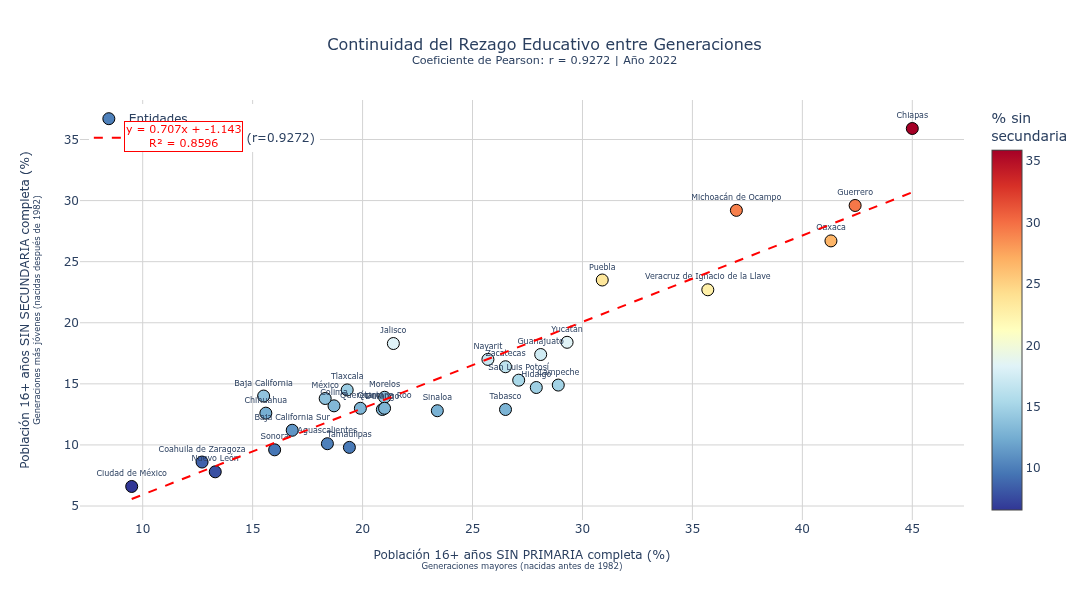

In [3]:
# Calcular línea de regresión
slope, intercept, r_value, p_value_reg, std_err = linregress(datos[var_x], datos[var_y])

# Crear valores para la línea de tendencia
x_line = np.linspace(datos[var_x].min(), datos[var_x].max(), 100)
y_line = slope * x_line + intercept

# Crear figura
fig = go.Figure()

# Agregar puntos de dispersión con nombres de estados
fig.add_trace(go.Scatter(
    x=datos[var_x],
    y=datos[var_y],
    mode='markers+text',
    text=datos['estado'],
    textposition='top center',
    textfont=dict(size=8),
    marker=dict(
        size=12,
        color=datos[var_y],
        colorscale='RdYlBu_r',
        showscale=True,
        colorbar=dict(title='% sin<br>secundaria'),
        line=dict(width=1, color='black')
    ),
    hovertemplate='<b>%{text}</b><br>' +
                  'Sin primaria: %{x:.1f}%<br>' +
                  'Sin secundaria: %{y:.1f}%<extra></extra>',
    name='Entidades'
))

# Agregar línea de tendencia
fig.add_trace(go.Scatter(
    x=x_line,
    y=y_line,
    mode='lines',
    line=dict(color='red', width=2, dash='dash'),
    name=f'Línea de tendencia (r={corr:.4f})'
))

# Configurar layout con ejes bien etiquetados
fig.update_layout(
    title={
        'text': f'Continuidad del Rezago Educativo entre Generaciones<br><sup>Coeficiente de Pearson: r = {corr:.4f} | Año {ANIO}</sup>',
        'x': 0.5,
        'xanchor': 'center',
        'font': dict(size=16)
    },
    xaxis=dict(
        title=dict(
            text='Población 16+ años SIN PRIMARIA completa (%)<br><sup>Generaciones mayores (nacidas antes de 1982)</sup>',
            font=dict(size=12)
        ),
        gridcolor='lightgray',
        zeroline=False
    ),
    yaxis=dict(
        title=dict(
            text='Población 16+ años SIN SECUNDARIA completa (%)<br><sup>Generaciones más jóvenes (nacidas después de 1982)</sup>',
            font=dict(size=12)
        ),
        gridcolor='lightgray',
        zeroline=False
    ),
    template='plotly_white',
    showlegend=True,
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    ),
    height=600,
    width=900
)

# Agregar anotación con ecuación
fig.add_annotation(
    x=0.05,
    y=0.95,
    xref='paper',
    yref='paper',
    text=f'y = {slope:.3f}x + {intercept:.3f}<br>R² = {r_value**2:.4f}',
    showarrow=False,
    font=dict(size=11, color='red'),
    bgcolor='white',
    bordercolor='red',
    borderwidth=1
)

fig.show()

## 📊 Distribución de Variables

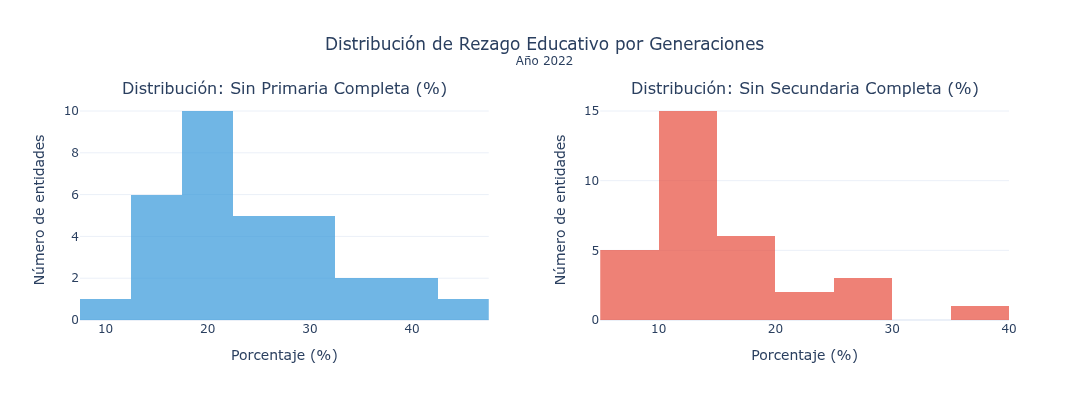

In [4]:
# Crear histogramas comparativos
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        'Distribución: Sin Primaria Completa (%)',
        'Distribución: Sin Secundaria Completa (%)'
    ),
    horizontal_spacing=0.12
)

# Histograma variable X
fig.add_trace(
    go.Histogram(
        x=datos[var_x],
        nbinsx=10,
        name='Sin primaria',
        marker_color='#3498db',
        opacity=0.7,
        hovertemplate='Rango: %{x}%<br>Frecuencia: %{y} estados<extra></extra>'
    ),
    row=1, col=1
)

# Histograma variable Y
fig.add_trace(
    go.Histogram(
        x=datos[var_y],
        nbinsx=10,
        name='Sin secundaria',
        marker_color='#e74c3c',
        opacity=0.7,
        hovertemplate='Rango: %{x}%<br>Frecuencia: %{y} estados<extra></extra>'
    ),
    row=1, col=2
)

# Actualizar ejes
fig.update_xaxes(title_text='Porcentaje (%)', row=1, col=1)
fig.update_xaxes(title_text='Porcentaje (%)', row=1, col=2)
fig.update_yaxes(title_text='Número de entidades', row=1, col=1)
fig.update_yaxes(title_text='Número de entidades', row=1, col=2)

fig.update_layout(
    title_text=f'Distribución de Rezago Educativo por Generaciones<br><sup>Año {ANIO}</sup>',
    title_x=0.5,
    showlegend=False,
    height=400,
    template='plotly_white'
)

fig.show()

## 🗺️ Mapa de Entidades: Rezago Educativo Comparado

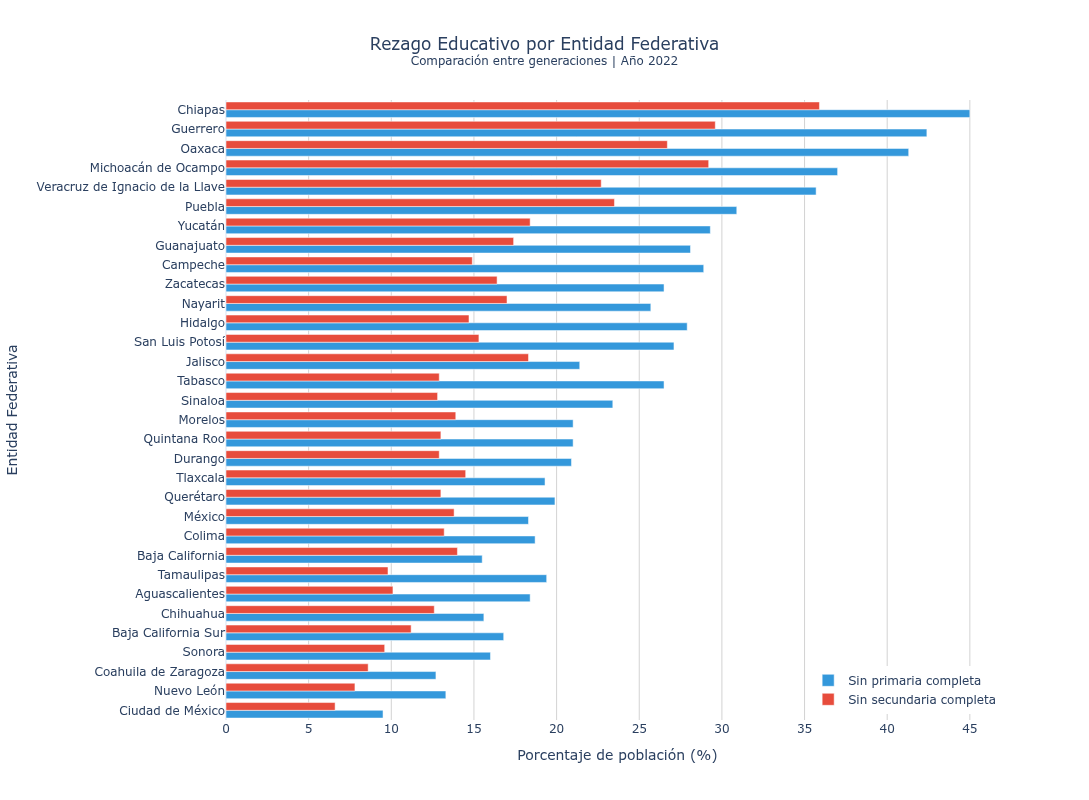

In [5]:
# Ordenar datos por rezago
datos_sorted = datos.sort_values(var_x, ascending=True)

# Crear gráfico de barras horizontales comparativo
fig = go.Figure()

# Barras para sin primaria
fig.add_trace(go.Bar(
    y=datos_sorted['estado'],
    x=datos_sorted[var_x],
    name='Sin primaria completa',
    orientation='h',
    marker_color='#3498db',
    hovertemplate='%{y}<br>Sin primaria: %{x:.1f}%<extra></extra>'
))

# Barras para sin secundaria
fig.add_trace(go.Bar(
    y=datos_sorted['estado'],
    x=datos_sorted[var_y],
    name='Sin secundaria completa',
    orientation='h',
    marker_color='#e74c3c',
    hovertemplate='%{y}<br>Sin secundaria: %{x:.1f}%<extra></extra>'
))

fig.update_layout(
    title={
        'text': f'Rezago Educativo por Entidad Federativa<br><sup>Comparación entre generaciones | Año {ANIO}</sup>',
        'x': 0.5,
        'xanchor': 'center'
    },
    xaxis=dict(
        title='Porcentaje de población (%)',
        gridcolor='lightgray'
    ),
    yaxis=dict(
        title='Entidad Federativa',
        categoryorder='total ascending'
    ),
    barmode='group',
    height=800,
    width=900,
    template='plotly_white',
    legend=dict(
        x=0.99,
        y=0.01,
        xanchor='right',
        yanchor='bottom'
    )
)

fig.show()

## 🔍 Análisis de Extremos

In [6]:
print("🔝 TOP 5 - MAYOR REZAGO EDUCATIVO (Ambas generaciones)")
print("=" * 80)
top_rezago = datos.nlargest(5, var_x)[['estado', var_x, var_y]]
for idx, row in top_rezago.iterrows():
    print(f"\n{row['estado']}:")
    print(f"  • Sin primaria: {row[var_x]:.1f}%")
    print(f"  • Sin secundaria: {row[var_y]:.1f}%")
    print(f"  • Brecha: {row[var_y] - row[var_x]:.1f} puntos porcentuales")

print("\n" + "=" * 80)
print("🔝 TOP 5 - MENOR REZAGO EDUCATIVO (Ambas generaciones)")
print("=" * 80)
low_rezago = datos.nsmallest(5, var_x)[['estado', var_x, var_y]]
for idx, row in low_rezago.iterrows():
    print(f"\n{row['estado']}:")
    print(f"  • Sin primaria: {row[var_x]:.1f}%")
    print(f"  • Sin secundaria: {row[var_y]:.1f}%")
    print(f"  • Brecha: {row[var_y] - row[var_x]:.1f} puntos porcentuales")

🔝 TOP 5 - MAYOR REZAGO EDUCATIVO (Ambas generaciones)

Chiapas:
  • Sin primaria: 45.0%
  • Sin secundaria: 35.9%
  • Brecha: -9.1 puntos porcentuales

Guerrero:
  • Sin primaria: 42.4%
  • Sin secundaria: 29.6%
  • Brecha: -12.8 puntos porcentuales

Oaxaca:
  • Sin primaria: 41.3%
  • Sin secundaria: 26.7%
  • Brecha: -14.6 puntos porcentuales

Michoacán de Ocampo:
  • Sin primaria: 37.0%
  • Sin secundaria: 29.2%
  • Brecha: -7.8 puntos porcentuales

Veracruz de Ignacio de la Llave:
  • Sin primaria: 35.7%
  • Sin secundaria: 22.7%
  • Brecha: -13.0 puntos porcentuales

🔝 TOP 5 - MENOR REZAGO EDUCATIVO (Ambas generaciones)

Ciudad de México:
  • Sin primaria: 9.5%
  • Sin secundaria: 6.6%
  • Brecha: -2.9 puntos porcentuales

Coahuila de Zaragoza:
  • Sin primaria: 12.7%
  • Sin secundaria: 8.6%
  • Brecha: -4.1 puntos porcentuales

Nuevo León:
  • Sin primaria: 13.3%
  • Sin secundaria: 7.8%
  • Brecha: -5.5 puntos porcentuales

Baja California:
  • Sin primaria: 15.5%
  • Sin secun

## 📊 Matriz de Correlación Contextual

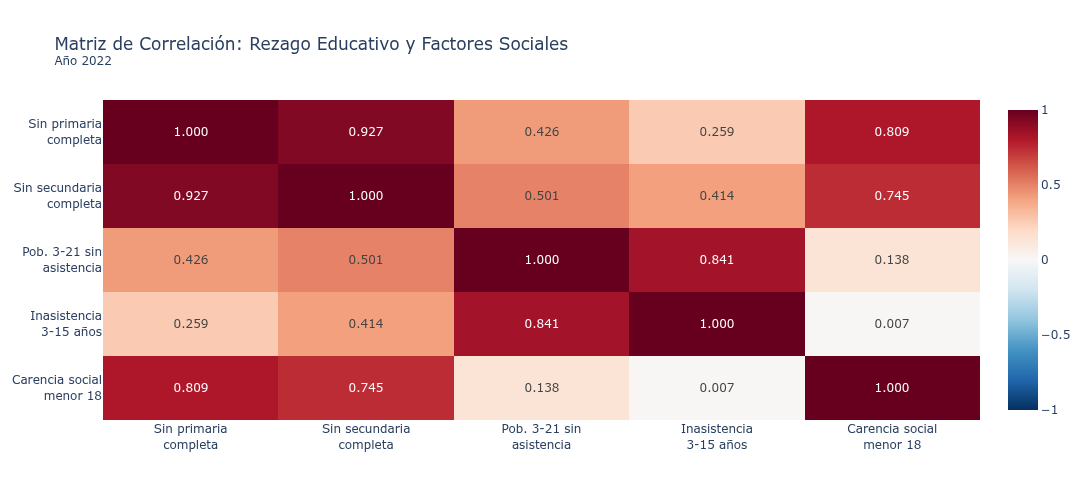

In [7]:
# Crear matriz de correlación con variables relacionadas
vars_corr = [
    'porc_pob_16mas_sin_prim',
    'porc_pob_16mas_sin_secu',
    'porc_pob_3_21_no_asist_sin_oblig',
    'porc_tasa_inasistencia_3_15',
    'porc_carencia_menor18'
]

# Calcular matriz de correlación
corr_matrix = df_analisis[vars_corr].corr()

# Crear heatmap
labels = [
    'Sin primaria<br>completa',
    'Sin secundaria<br>completa',
    'Pob. 3-21 sin<br>asistencia',
    'Inasistencia<br>3-15 años',
    'Carencia social<br>menor 18'
]

fig = px.imshow(
    corr_matrix,
    text_auto='.3f',
    aspect='auto',
    color_continuous_scale='RdBu_r',
    zmin=-1,
    zmax=1,
    x=labels,
    y=labels,
    title=f'Matriz de Correlación: Rezago Educativo y Factores Sociales<br><sup>Año {ANIO}</sup>'
)

fig.update_layout(
    height=500,
    width=600,
    xaxis=dict(tickangle=0),
    yaxis=dict(tickangle=0)
)

fig.show()

## 💡 Interpretación y Conclusiones

### Hallazgos Clave

1. **Correlación casi perfecta (r=0.91):** La relación entre rezago educativo de generaciones mayores y jóvenes es extremadamente fuerte, lo que indica una **perpetuación estructural del desigualdad educativa**.

2. **Transmisión intergeneracional:** Los estados con baja cobertura de primaria en el pasado (Chiapas, Oaxaca, Guerrero) mantienen baja cobertura de secundaria en el presente.

3. **Brecha regional persistente:** Existe una clara división entre:
   - **Sur-Sureste** (mayor rezago): Chiapas, Oaxaca, Guerrero, Veracruz
   - **Norte-Centro** (menor rezago): Baja California, Ciudad de México, Nuevo León

4. **Diferencia temporal:** Aunque el rezago de primaria disminuyó en décadas recientes, la estructura geográfica del rezago se mantiene prácticamente igual.

### Implicaciones para Política Pública

- **Enfoque territorial:** Las intervenciones educativas deben priorizar las mismas regiones históricamente rezagadas
- **Intervención temprana:** Romper el ciclo requiere actuar antes de que se consolide el rezago
- **Políticas integrales:** El rezago educativo está fuertemente vinculado a carencias sociales multidimensionales

---

**Nota metodológica:** Este análisis compara cohortes generacionales diferentes. La cohorte "sin primaria" representa principalmente a personas nacidas antes de 1982, mientras que la cohorte "sin secundaria" incluye personas nacidas después de 1982.